# Masks analysis
Plots for the analysis of sergmentation masks

In [1]:
# Imports
from pathlib import Path
import dask.array as da
import zarr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Arial"

In [2]:
# Save and data paths
save_root = Path("../data/figures/paper/analysis")
save_root.mkdir(exist_ok=True, parents=True)

data_root = Path("../data/processed/segmented/Au_01-vol_01.zarr")

In [3]:
# Load data
data_cells = pd.read_parquet(data_root / "labels/cells/tables/regionprops.parquet")
data_nuclei = pd.read_parquet(data_root / "labels/nuclei/tables/regionprops.parquet")
data_nps = pd.read_parquet(data_root / "labels/nps/tables/regionprops.parquet")

## Plot sizes

### Cells and nuclei

In [4]:
# Massage data for seaborn plotting
data_plot = pd.concat(
    [
        data_cells.assign(**{"seg_target": "Cells"}),
        data_nuclei.assign(**{"seg_target": "Nuclei"}),
    ],
    axis=0,
)

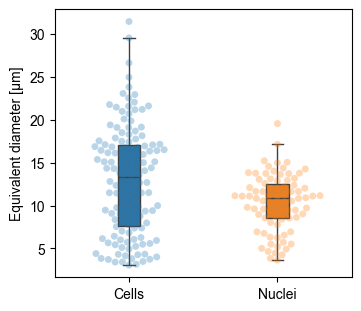

In [5]:
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
sns.boxplot(
    data_plot,
    y="equivalent_diameter_area",
    x="seg_target",
    hue="seg_target",
    showfliers=False,
    width=0.15,
)
sns.swarmplot(
    data_plot, y="equivalent_diameter_area", x="seg_target", hue="seg_target", alpha=0.3
)
ax.set(xlabel="", ylabel="Equivalent diameter [µm]")
fig.savefig(
    save_root / "Cellular-structure-diameter.pdf", bbox_inches="tight", pad_inches=0.01
)

### Nuclei
Nuclei are more difficult to describe by size because there's a huge distribution of sizes

In [6]:
data_nps["volume_fraction"] = data_nps["area"] / data_nps["area"].sum()

# Select top N aggregates
top_quantile = 0.005
data_plot = data_nps.loc[
    data_nps["area"] >= data_nps["area"].quantile(1 - top_quantile)
]

/var/folders/8z/369htdbn1q54nlcycfst406m0000gp/T/ipykernel_66123/3724065786.py:6: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set(


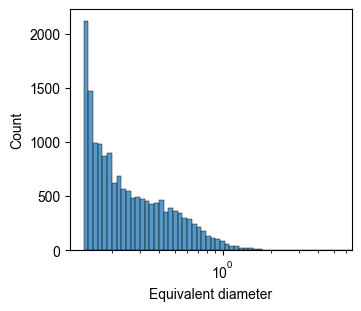

In [7]:
# Plot all the NPs

fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
sns.histplot(data_nps, x="equivalent_diameter_area", ax=ax, log_scale=True)
# sns.swarmplot(data_plot, y="equivalent_diameter_area", x="seg_target", hue="seg_target", alpha=0.3)
ax.set(
    xlim=[0, data_nps["equivalent_diameter_area"].max()], xlabel="Equivalent diameter"
)
fig.savefig(
    save_root / "NPs-agg-diameter-all.pdf", bbox_inches="tight", pad_inches=0.01
)

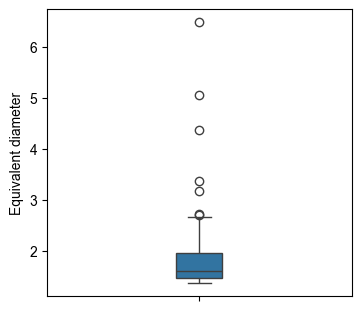

In [8]:
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
sns.boxplot(
    data_plot,
    y="equivalent_diameter_area",
    # x="seg_target",
    # hue="seg_target",
    showfliers=True,
    width=0.15,
)

ax.set(xlabel="", ylabel="Equivalent diameter")
fig.savefig(
    save_root / f"NPs-agg-diameter-{1 - top_quantile}.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

## Uptake

In [9]:
# Calculate mass
# density: g / µm^3
density_gold = 19.32 * 1e-15
data_nps["mass"] = data_nps["area"] * density_gold
data_uptake = data_nps.groupby("parent_cell", as_index=False)[
    ["mass", "area"]
].aggregate("sum")
data_uptake["object"] = "NPs"

<Axes: xlabel='mass', ylabel='Count'>

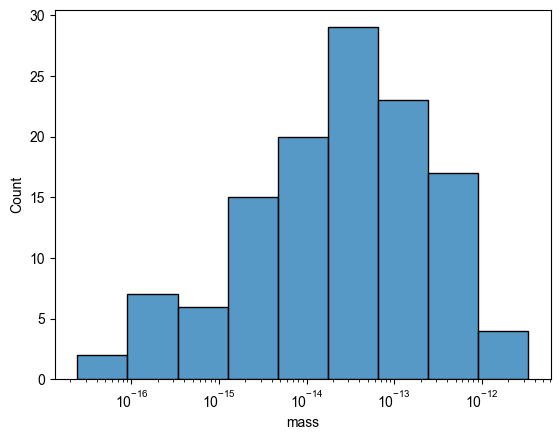

In [10]:
fig, ax = plt.subplots()
sns.histplot(
    data_uptake.iloc[1:],
    x="mass",
    ax=ax,
    log_scale=True,
)

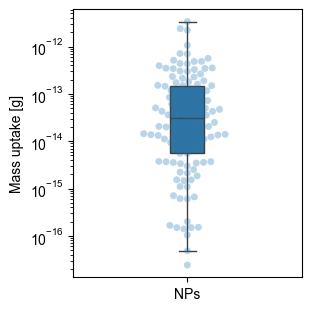

In [52]:
# Mass uptake per cell
fig, ax = plt.subplots(layout="constrained", figsize=(3, 3))
sns.boxplot(
    data_uptake.iloc[1:],
    y="mass",
    x="object",
    ax=ax,
    log_scale=True,
    showfliers=False,
    width=0.15,
    hue="object",
)
sns.swarmplot(data_uptake.iloc[1:], x="object", y="mass", alpha=0.3, hue="object")
ax.set(xlabel="", ylabel="Mass uptake [g]")
fig.savefig(save_root / "NP-uptake-per-cell.pdf", bbox_inches="tight", pad_inches=0.01)

[Text(0.5, 0, 'Realative NP volume fraction')]

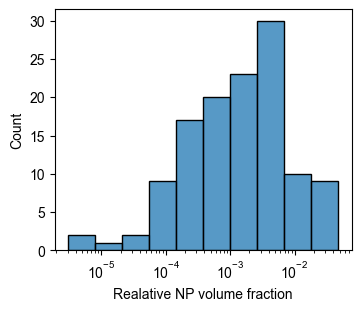

In [12]:
# Relative volume fraction of uptaken nanoparticles
data_cells_uptake = pd.merge(
    left=data_cells,
    right=data_uptake.rename(columns={"mass": "np_mass", "area": "np_volume"}),
    left_on="label",
    right_on="parent_cell",
    how="left",
)
data_cells_uptake["np_volume_rel"] = (
    data_cells_uptake["np_volume"] / data_cells_uptake["area"]
)

fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
sns.histplot(
    data_cells_uptake,
    x="np_volume_rel",
    ax=ax,
    log_scale=True,
)
ax.set(xlabel="Realative NP volume fraction")

## Distance from nucleus

### Voxel-wise distance

In [13]:
# Read distance data
dist = zarr.open_array(data_root / "labels/nuclei/distance/50-50-50")
nps = zarr.open_array(data_root / "labels/nps/masks/50-50-50")

dist_dask = da.from_zarr(dist)
nps_dask = da.from_zarr(nps)

In [14]:
dist_nps_dask = dist_dask[nps_dask > 0]
dist_nps = dist_nps_dask.compute()

dist_nps = pd.DataFrame(dist_nps, columns=["distance"])
dist_nps["object"] = "NPs"

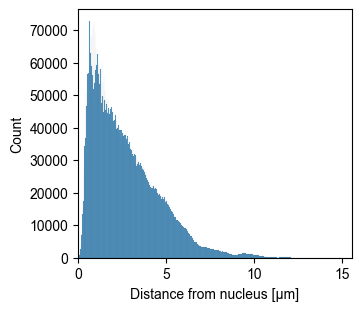

In [15]:
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
sns.histplot(dist_nps, x="distance")
ax.set(xlim=[0, dist_nps["distance"].max()], xlabel="Distance from nucleus [µm]")
fig.savefig(
    save_root / "NP-nuclei-distance-dist.pdf", bbox_inches="tight", pad_inches=0.01
)

[Text(0, 0.5, 'Distance from nucleus [µm]')]

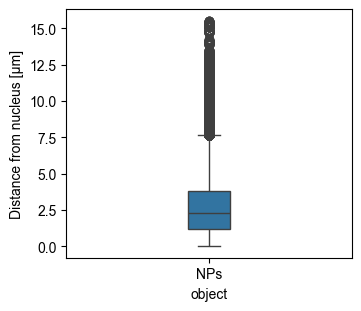

In [16]:
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
sns.boxplot(
    dist_nps,
    y="distance",
    x="object",
    ax=ax,
    showfliers=True,
    width=0.15,
    hue="object",
)
ax.set(ylabel="Distance from nucleus [µm]")

### Agglomerate-wise

In [17]:
data_nps["centroid"] = data_nps.apply(
    lambda x: tuple(int(x[f"centroid-{i}"] / x[f"spacing_um-{i}"]) for i in range(3)),
    axis=1,
)

centroid_idxs = data_nps["centroid"].to_list()
centroid_idxs = [np.array([c[i] for c in centroid_idxs]) for i in range(3)]

data_nps["dist_centroid"] = dist[*centroid_idxs]
data_nps["object"] = "NPs"

In [18]:
data_plot = data_nps.copy()
data_plot["distance"] = data_plot["dist_centroid"]
data_plot["kind"] = "Aggregate"

data_plot = pd.concat([dist_nps.assign(**{"kind": "Voxel"}), data_plot]).reset_index()

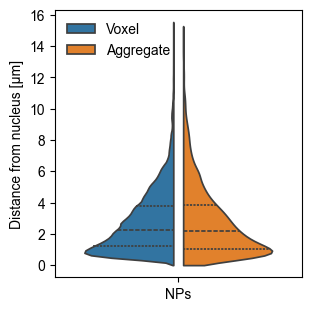

In [19]:
fig, ax = plt.subplots(layout="constrained", figsize=(3, 3))
sns.violinplot(
    data_plot,
    x="object",
    y="distance",
    ax=ax,
    hue="kind",
    cut=0,
    split=True,
    inner="quart",
    gap=0.1,
)
ax.set(
    xlabel="",
    ylabel="Distance from nucleus [µm]",
    # ylim=[0, 16]
)
# ax.set_xticks([])
leg = ax.get_legend()
leg.set(title="", frame_on=False, loc="upper left")
fig.savefig(
    save_root / "NP-nuclei-distance-comparison.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

## Cell shape

In [22]:
# Massage data for seaborn plotting
data_plot = pd.concat(
    [
        data_cells.assign(**{"seg_target": "Cells"}),
        data_nuclei.assign(**{"seg_target": "Nuclei"}),
    ],
    axis=0,
)

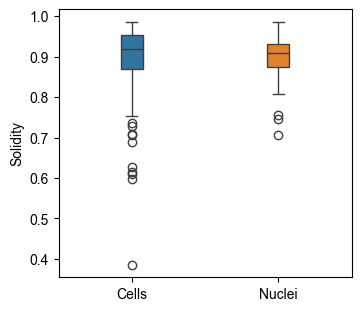

In [57]:
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
sns.boxplot(
    data_plot,
    y="solidity",
    x="seg_target",
    hue="seg_target",
    showfliers=True,
    width=0.15,
)
# sns.stripplot(
#     data_plot, y="solidity", x="seg_target", hue="seg_target", alpha=0.2
# )
ax.set(xlabel="", ylabel="Solidity")
fig.savefig(
    save_root / "Cellular-structure-solidity.pdf", bbox_inches="tight", pad_inches=0.01
)

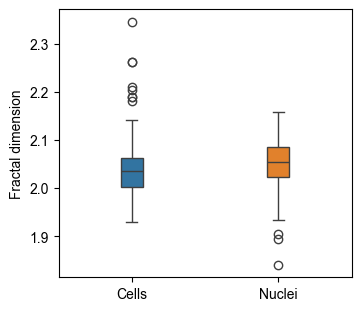

In [56]:
fig, ax = plt.subplots(layout="constrained", figsize=(3.5, 3))
# sns.violinplot(
#     data_plot,
#     y="fractal_dim",
#     x="seg_target",
#     hue="seg_target",
#     cut=0
# )
sns.boxplot(
    data_plot,
    y="fractal_dim",
    x="seg_target",
    hue="seg_target",
    showfliers=True,
    width=0.15,
)
ax.set(xlabel="", ylabel="Fractal dimension")
fig.savefig(
    save_root / "Cellular-structure-fractal-dimension.pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)